# Regression Analysis

Currently designed to analyze a single file

**Goals**
1. Curve Fit exponential decay
2. Curve Fit oscillations
2. Curve Fit exponential decay and oscillations
3. Fix y-axis scale
4. adjust x-axis scale to new 0 point
5. add error bars?

## Data Preparation

**Import Libraries**

In [60]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import numpy as np
from scipy.optimize import curve_fit


**Download Files**

In [61]:
col_names = ['Position(mm)', 'Voltage(V)', 'Phase(Theta)'] # Assign custom names

metal = "antimony" # Choose metal (bismuth or antimony)

power = "104.6" # Choose power

df = pd.read_csv(f"{metal}/data/{power}.txt", sep=r"\s+", header=None, names=col_names)

''' Multi-file regression
files = glob.glob(f"{metal}/data/*.txt") # Download files
files = sorted(files) # Sort files '''

' Multi-file regression\nfiles = glob.glob(f"{metal}/data/*.txt") # Download files\nfiles = sorted(files) # Sort files '

**Define Constants**

In [62]:
# speed of light
c = 299792458

# trial length (bismuth: 81, antimony: 161)
trial_len = -1 
if metal == "bismuth":
    trial_len = 81
if metal == "antimony":
    trial_len = 161

**Create Arrays**

In [63]:
position = df["Position(mm)"]
voltage = df["Voltage(V)"] 
time = 2 * (position / 10**3) / c
# Convert voltage from volts to microvolts (10^-6)
voltage = voltage * 10**6

# Convert time from seconds to picoseconds (10^-12)
time = time * 10**12

**Average Trials**

In [64]:
# Separate and average trial runs for each power and each sample

voltage = voltage.groupby(voltage.index % trial_len).mean().reset_index(drop=True)
time = time[ : trial_len]

## Regression Modeling

### Basic Exponential Decay Fitting

**Equation of Motion**

$$ Q(t) = Ae^{-b(t-t_0)} + c, \space t \geq t_0 $$

**Fit Model to Data**

In [65]:
def exp_decay_model(t, A, b, c, t0):
    return A * np.exp(-b * (t - t0)) + c

# Give zero weight to points before the estimated onset
def fit_with_auto_weights(x_data, y_data):
    peak_idx = np.argmin(y_data)
    sigma = np.ones_like(y_data)
    sigma[:peak_idx] = 1e6  # effectively ignore pre-peak points

    p0 = [y_data[peak_idx] - y_data[-1], 0.01,
          y_data[-1], 139]
    
    popt, _ = curve_fit(exp_decay_model, x_data, y_data,
                            p0=p0, sigma=sigma, maxfev=20000)
    return popt

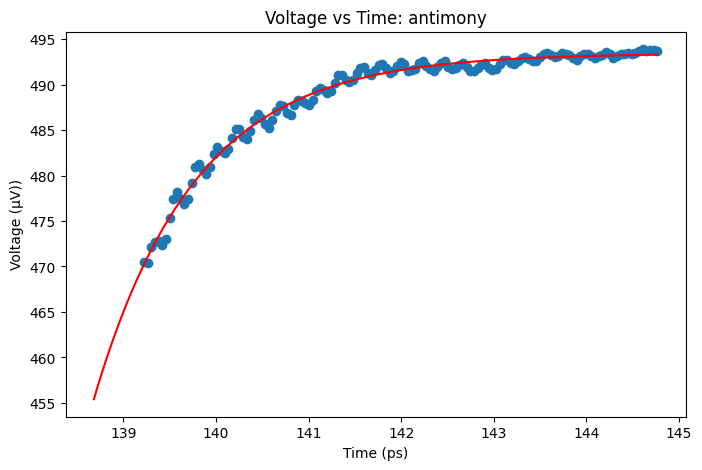

[-23.05953638   0.91235413 493.43407948 139.22838859]


In [66]:
time_np = time.to_numpy()
voltage_np = voltage.to_numpy()


popt = fit_with_auto_weights(time_np, voltage_np)
a, b, c, t0 = popt

# Smooth time range
t_smooth = np.linspace(138, np.max(time_np), 200)


# Create and size figure
fig = plt.figure(figsize=(8,5))

# Plot data
plt.scatter(time_np[20:], voltage_np[20:])

# Plot model
plt.plot(
    t_smooth[20:],
    exp_decay_model(t_smooth, a, b, c, t0)[20:],
    color = "r"
)

plt.xlabel("Time (ps)")
plt.ylabel("Voltage (\u00B5V))")
plt.title(f"Voltage vs Time: {metal}")


plt.show()

print(popt)


### Sine Fitting

**Equation of Motion**

$$ Q(t) = Asin(\omega t + \phi) + d $$

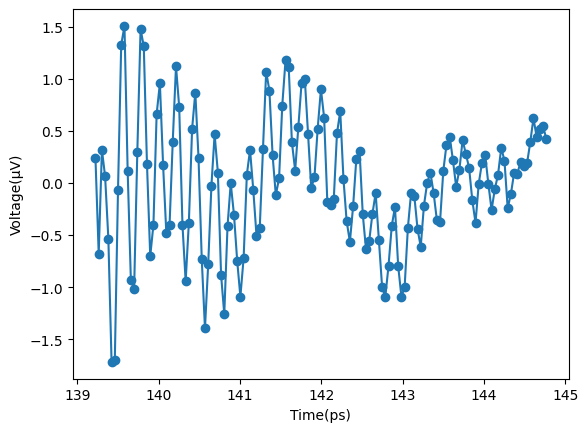

161
161
161


In [67]:
no_exp_voltage = voltage_np - exp_decay_model(time_np, a, b, c, t0)

plt.figure()
plt.plot(time_np[20:], no_exp_voltage[20:])
plt.scatter(time_np[20:], no_exp_voltage[20:])
plt.xlabel("Time(ps)")
plt.ylabel(f"Voltage(\u00B5V)")
#plt.title(f"{metal} (power : {power} mW)")

# plt.savefig(f"{metal}_{power}.pdf")
plt.show()

print(len(time_np))
print(len(time))
print(len(no_exp_voltage))

### Paper Inspired Fit

**Equation of Motion**

$$ \frac{\Delta R}{R} = \frac{1}{2}\left[1-\text{erf}\left(\frac{t-t_{0}}{\tau_{1}}\right)\right]\left[A_{0}e^{-\frac{t-t_{0}}{\tau_{1}}} + A_{1} + A_{\text{osc}}e^{-\frac{t-t_{0}}{\tau_{\text{osc}}}}cos(\omega_{\text{osc}}t + \phi_{\text{osc}}) \right]  $$

**Envelope**

$$ \text{envelope} = \frac{1}{2}\left[1-\text{erf}\left(\frac{t-t_{0}}{\tau_{1}}\right)\right]\left[A_{0}e^{-\frac{t-t_{0}}{\tau_{1}}} + A_{1} \right] $$

$$ \text{signal} = \frac{\Delta R}{R} - \text{envelope} = \frac{1}{2}\left[1-\text{erf}\left(\frac{t-t_{0}}{\tau_{1}}\right)\right]\left[A_{\text{osc}}e^{-\frac{t-t_{0}}{\tau_{\text{osc}}}}cos(\omega_{\text{osc}}t + \phi_{\text{osc}}) \right] $$ 

### ISRS Excitation Fitting

**Equation of Motion**

$$ Q(t) = A\Theta(t-t_{0})e^{-\gamma (t-t_{0})}\sin{\left[\sqrt{\omega_{0}^2-\gamma^2}(t-t_{0})\right]} + C $$

In [103]:
def ISRS_model(t, A, gamma, omega, c, t0):
    return A * np.heaviside(t - t0, 1) * np.exp(-gamma * (t - t0)) * np.sin(np.sqrt(omega**2 - gamma**2) * (t-t0)) + c






def fit_with_auto_weights(x_data, y_data):
    peak_idx = np.argmin(y_data)
    sigma = np.ones_like(y_data)
    sigma[:peak_idx] = 1e10  # effectively ignore pre-peak points


    c_guess = np.mean(y_data[-20:])
    a_guess = y_data[peak_idx] - c_guess

    period_guess = 5  # ps, estimated from the plot
    omega_guess = 2 * np.pi / period_guess  # ~1.26 rad/ps

    p0 = [
        a_guess,
        0.5,            # gamma: smaller than omega to ensure oscillation
        omega_guess,
        c_guess,
        x_data[peak_idx],
    ]

    # Force omega > gamma so sqrt(omega²-gamma²) stays real and oscillatory
    bounds = (
        [-np.inf, 1e-6, omega_guess * 0.5, -np.inf, x_data[peak_idx] - 0.5],
        [np.inf,  1.0,  omega_guess * 3,    np.inf,  x_data[peak_idx] + 0.5],
    )


    p0 = [np.clip(p, lo, hi) for p, lo, hi in zip(p0, bounds[0], bounds[1])]
    
    popt, _ = curve_fit(ISRS_model, x_data, y_data,
                            p0=p0, sigma=sigma, bounds=bounds, maxfev=50000)

    return popt

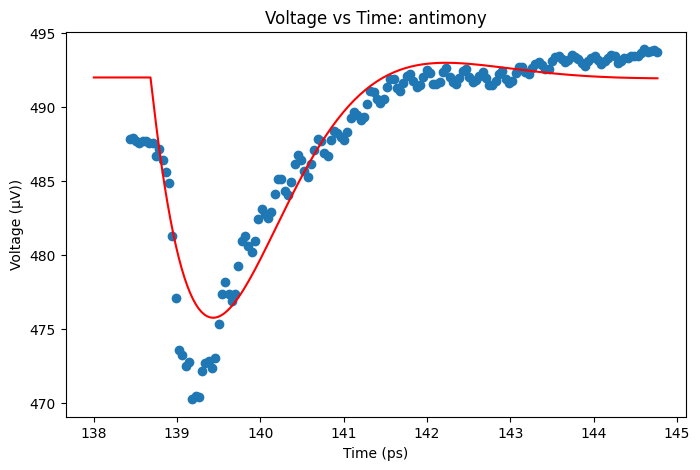

[-46.00668623   1.           1.50452185 491.9801858  138.68162011]


In [104]:
popt = fit_with_auto_weights(time_np, voltage_np)
a, gamma, omega, c, t0 = popt

# Smooth time range
t_smooth = np.linspace(138, np.max(time_np), 200)


# Create and size figure
fig = plt.figure(figsize=(8,5))

# Plot data
plt.scatter(time_np, voltage_np)

# Plot model
plt.plot(
    t_smooth,
    ISRS_model(t_smooth, a, gamma, omega, c, t0),
    color = "r"
)

plt.xlabel("Time (ps)")
plt.ylabel("Voltage (\u00B5V))")
plt.title(f"Voltage vs Time: {metal}")


plt.show()

print(popt)


### DECP Excitation Fitting 

**Equation of Motion**

$$ Q(t) = B\frac{\kappa \Delta n}{\omega_{0}^2}\left(1 - e^{-\gamma t}\cos{\left[\sqrt{\omega_{0}^2-\gamma^2}t\right]}\right) $$ 